# Notebook 3 - Analisis del Dato

Este cuaderno inicia el pilar de Analisis del Dato a partir del dataset municipal enriquecido generado en la fase de Ingenieria del Dato.

La unidad de observacion original es `municipio-dia`, pero en este notebook se construyen tambien agregaciones municipales para estudiar patrones temporales, diferencias territoriales, eventos climaticos intensos y una primera aproximacion a riesgo y vulnerabilidad.

La entrada principal es:

`DATA/PROCESSED/dataset_cv_municipios_enriched.csv`

Como variable adicional se incorpora, si esta disponible, la altitud aproximada de la coordenada ERA5-Land asignada a cada municipio:

`DATA/PROCESSED/municipios_altitud_openmeteo.csv`


## 0. Configuracion inicial

Se cargan las librerias necesarias y se definen las rutas de trabajo. Este notebook no vuelve a construir el dataset, sino que parte de las salidas ya cerradas en Ingenieria del Dato.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"

DATASET_FILE = PROC / "dataset_cv_municipios_enriched.csv"
ALTITUDE_FILE = PROC / "municipios_altitud_openmeteo.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"

ANALYTIC_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_analisis_municipal.csv"

MAPS.mkdir(parents=True, exist_ok=True)

print("Dataset de analisis:", DATASET_FILE)
print("Existe:", DATASET_FILE.exists())
print("Altitud disponible:", ALTITUDE_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())

Dataset de analisis: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_enriched.csv
Existe: True
Altitud disponible: True
Geometria municipal disponible: True


## 1. Carga del dataset y comprobaciones basicas

El primer paso consiste en verificar que el dataset conserva la cobertura esperada: 542 municipios, periodo 2019-2024 y una observacion por municipio y dia.


In [2]:
df = pd.read_csv(DATASET_FILE, parse_dates=["fecha"])

print("Shape:", df.shape)
print("Municipios:", df["municipio"].nunique())
print("Rango temporal:", df["fecha"].min().date(), "->", df["fecha"].max().date())
print("Dias unicos:", df["fecha"].nunique())
print("Duplicados municipio-fecha:", df.duplicated(subset=["municipio", "fecha"]).sum())

display(df.head())

Shape: (1188064, 22)
Municipios: 542
Rango temporal: 2019-01-01 -> 2024-12-31
Dias unicos: 2192
Duplicados municipio-fecha: 0


,municipio,CODNUT2,CODNUT3,fecha,temp_media_dia,temp_max_dia,temp_min_dia,viento_medio_dia,viento_max_dia,lon,lat,dist_metros,precip_total_dia,amplitud_termica_dia,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar
0,Ademuz,ES52,ES523,2019-01-01,2.735280,12.305084,-2.840179,1.430405,1.927332,-1.2,40.1,5806.682345,0.000000,15.145263,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
1,Ademuz,ES52,ES523,2019-01-02,1.408661,8.768463,-2.744965,2.487614,3.134458,-1.2,40.1,5806.682345,0.000860,11.513428,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
2,Ademuz,ES52,ES523,2019-01-03,1.463847,7.518707,-3.328705,1.271294,1.983465,-1.2,40.1,5806.682345,0.000000,10.847412,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
3,Ademuz,ES52,ES523,2019-01-04,1.935232,10.640778,-4.029633,1.283369,1.690730,-1.2,40.1,5806.682345,0.000852,14.670411,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0
4,Ademuz,ES52,ES523,2019-01-05,1.852412,10.552155,-4.144867,2.385710,3.107875,-1.2,40.1,5806.682345,0.000000,14.697022,100.29,46001,1015.0,10.12,26.8,11.82,226.67,27809.0


In [4]:
id_cols = ["municipio", "CODNUT2", "CODNUT3", "fecha"]

climate_cols = [
    "precip_total_dia",
    "temp_media_dia",
    "temp_max_dia",
    "temp_min_dia",
    "viento_medio_dia",
    "viento_max_dia",
    "amplitud_termica_dia",
]

spatial_cols = ["lon", "lat", "dist_metros", "area_km2"]

territorial_cols = [
    "cod_ine",
    "poblacion_total",
    "densidad_poblacion",
    "mayores_65_pct",
    "menores_16_pct",
    "indice_envejecimiento",
    "renta_media_hogar",
]

print("Variables climaticas:", len(climate_cols))
print("Variables espaciales:", len(spatial_cols))
print("Variables territoriales:", len(territorial_cols))

Variables climaticas: 7
Variables espaciales: 4
Variables territoriales: 7


In [5]:
missing = (
    df[id_cols + climate_cols + spatial_cols + territorial_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("nulos")
)
missing["pct"] = (missing["nulos"] / len(df) * 100).round(3)

display(missing[missing["nulos"] > 0])

,nulos,pct
renta_media_hogar,17536,1.476
indice_envejecimiento,10960,0.923


## 2. Incorporacion de altitud aproximada

La altitud se incorpora como variable estatica municipal. En este caso representa la altitud aproximada de la coordenada ERA5-Land asignada al municipio, no la altitud media real de todo el termino municipal.

Su utilidad principal es ayudar a interpretar diferencias de temperatura, precipitacion y viento entre zonas litorales, interiores y de mayor elevacion.


In [6]:
if ALTITUDE_FILE.exists():
    df_alt = pd.read_csv(ALTITUDE_FILE)
    altitude_cols = ["municipio", "CODNUT2", "CODNUT3", "altitud_m"]
    df_alt = df_alt[altitude_cols].drop_duplicates(subset=["municipio", "CODNUT2", "CODNUT3"])

    df = df.merge(df_alt, on=["municipio", "CODNUT2", "CODNUT3"], how="left")
    print("Altitud incorporada.")
    print("Municipios sin altitud:", df.groupby("municipio")["altitud_m"].first().isna().sum())
else:
    df["altitud_m"] = np.nan
    print("No se encontro fichero de altitud. El analisis continua sin esta variable.")

display(df[["municipio", "lat", "lon", "altitud_m"]].drop_duplicates().head())

Altitud incorporada.
Municipios sin altitud: 0


,municipio,lat,lon,altitud_m
0,Ademuz,40.1,-1.2,907.0
2192,Ador,38.9,-0.2,79.0
4384,Agost,38.4,-0.6,181.0
6576,Agres,38.8,-0.5,756.0
8768,Agullent,38.8,-0.6,556.0


## 3. Analisis temporal de variables climaticas

Se agregan las observaciones diarias a escala mensual para observar tendencias generales y estacionalidad. Este analisis sirve para comprobar si las variables tienen un comportamiento climatologico plausible antes de pasar a indicadores municipales.


In [7]:
df_month = (
    df.assign(mes=df["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("mes", as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        temp_media=("temp_media_dia", "mean"),
        temp_max_media=("temp_max_dia", "mean"),
        viento_medio=("viento_medio_dia", "mean"),
    )
)

display(df_month.head())

,mes,precip_media_diaria,temp_media,temp_max_media,viento_medio
0,2019-01-01,0.146805,8.007917,13.462288,2.994654
1,2019-02-01,0.117051,9.741801,16.063344,2.577584
2,2019-03-01,0.877532,12.402223,18.518076,2.625422
3,2019-04-01,4.494653,13.049360,17.745502,3.150904
4,2019-05-01,0.972821,16.950787,22.141527,2.411726


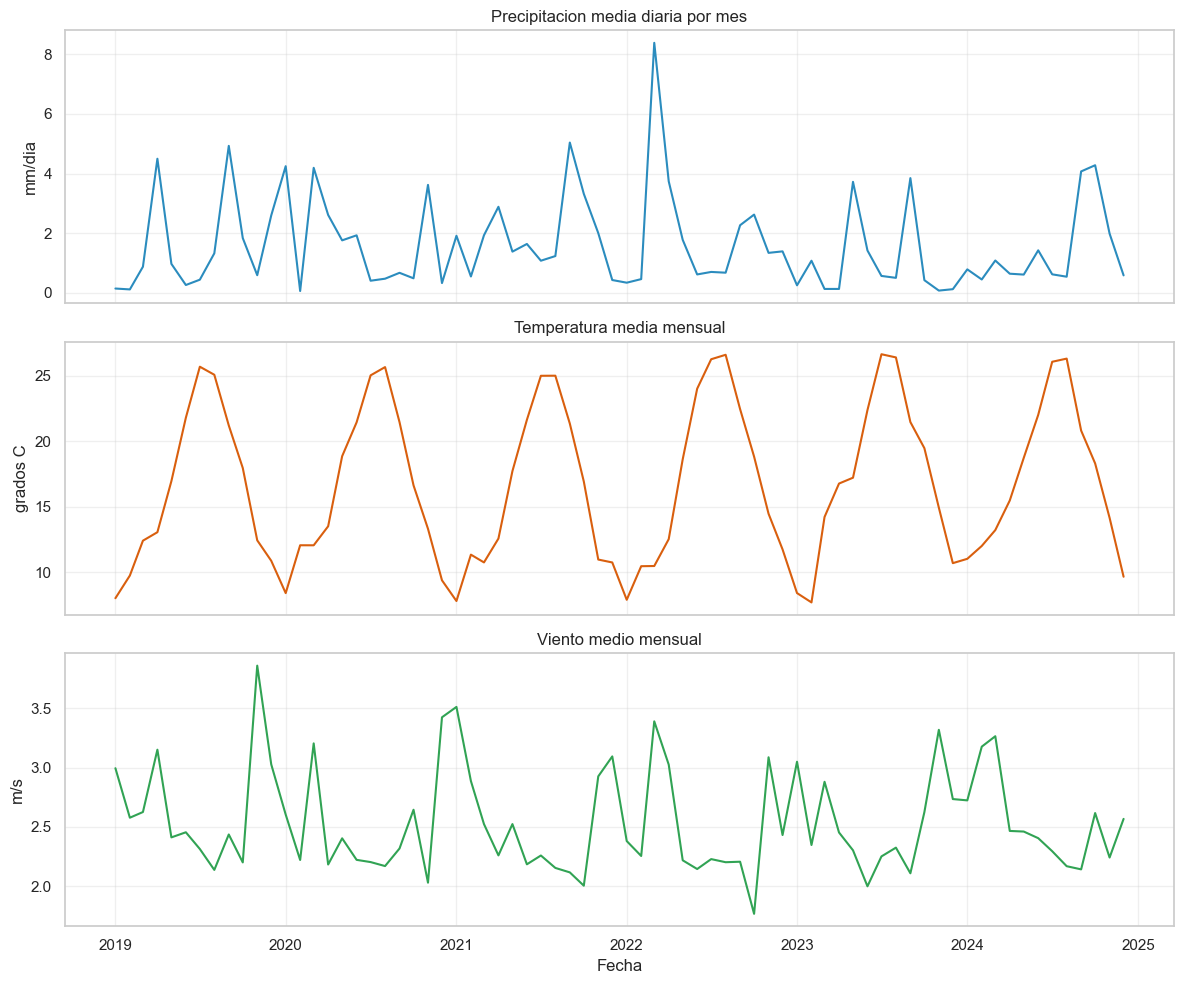

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df_month["mes"], df_month["precip_media_diaria"], color="#2b8cbe")
axes[0].set_title("Precipitacion media diaria por mes")
axes[0].set_ylabel("mm/dia")

axes[1].plot(df_month["mes"], df_month["temp_media"], color="#d95f0e")
axes[1].set_title("Temperatura media mensual")
axes[1].set_ylabel("grados C")

axes[2].plot(df_month["mes"], df_month["viento_medio"], color="#31a354")
axes[2].set_title("Viento medio mensual")
axes[2].set_ylabel("m/s")
axes[2].set_xlabel("Fecha")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
df_seasonality = (
    df.assign(mes_num=df["fecha"].dt.month)
    .groupby("mes_num", as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        temp_media=("temp_media_dia", "mean"),
        viento_medio=("viento_medio_dia", "mean"),
    )
)

display(df_seasonality)

,mes_num,precip_media_diaria,temp_media,viento_medio
0,1,1.282057,8.584712,2.877358
1,2,0.451260,10.562452,2.578834
2,3,2.765949,12.180525,2.981311
3,4,2.417854,13.977894,2.589740
4,5,1.704774,18.012521,2.386926
5,6,1.216731,22.209235,2.235231
6,7,0.637397,25.778980,2.258562
7,8,0.793609,25.839345,2.193058
8,9,3.469974,21.453574,2.221468
9,10,2.162147,18.015580,2.309752


## 4. Agregacion municipal e indicadores climaticos

Para comparar municipios se transforma el dataset diario en una tabla municipal. Se calculan indicadores medios y de cola alta, especialmente percentiles y dias por encima de umbrales globales.

Los umbrales globales permiten comparar todos los municipios con el mismo criterio.


In [10]:
thresholds = {
    "precip_p95_global": df["precip_total_dia"].quantile(0.95),
    "precip_p99_global": df["precip_total_dia"].quantile(0.99),
    "temp_max_p95_global": df["temp_max_dia"].quantile(0.95),
    "viento_max_p95_global": df["viento_max_dia"].quantile(0.95),
}

for name, value in thresholds.items():
    print(f"{name}: {value:.3f}")

precip_p95_global: 8.816
precip_p99_global: 27.111
temp_max_p95_global: 33.130
viento_max_p95_global: 7.076


In [11]:
df_mun = (
    df.groupby(["municipio", "CODNUT2", "CODNUT3"], as_index=False)
    .agg(
        precip_media_diaria=("precip_total_dia", "mean"),
        precip_max_dia=("precip_total_dia", "max"),
        precip_p95=("precip_total_dia", lambda s: s.quantile(0.95)),
        precip_p99=("precip_total_dia", lambda s: s.quantile(0.99)),
        dias_precip_intensa=("precip_total_dia", lambda s: (s >= thresholds["precip_p95_global"]).sum()),
        dias_precip_extrema=("precip_total_dia", lambda s: (s >= thresholds["precip_p99_global"]).sum()),
        temp_media_periodo=("temp_media_dia", "mean"),
        temp_max_media=("temp_max_dia", "mean"),
        temp_max_abs=("temp_max_dia", "max"),
        temp_p95=("temp_max_dia", lambda s: s.quantile(0.95)),
        dias_calor_intenso=("temp_max_dia", lambda s: (s >= thresholds["temp_max_p95_global"]).sum()),
        temp_min_abs=("temp_min_dia", "min"),
        viento_medio_periodo=("viento_medio_dia", "mean"),
        viento_max_abs=("viento_max_dia", "max"),
        viento_p95=("viento_max_dia", lambda s: s.quantile(0.95)),
        dias_viento_intenso=("viento_max_dia", lambda s: (s >= thresholds["viento_max_p95_global"]).sum()),
        amplitud_termica_media=("amplitud_termica_dia", "mean"),
        lon=("lon", "first"),
        lat=("lat", "first"),
        dist_metros=("dist_metros", "first"),
        area_km2=("area_km2", "first"),
        cod_ine=("cod_ine", "first"),
        poblacion_total=("poblacion_total", "first"),
        densidad_poblacion=("densidad_poblacion", "first"),
        mayores_65_pct=("mayores_65_pct", "first"),
        menores_16_pct=("menores_16_pct", "first"),
        indice_envejecimiento=("indice_envejecimiento", "first"),
        renta_media_hogar=("renta_media_hogar", "first"),
        altitud_m=("altitud_m", "first"),
    )
)

print("Shape agregado municipal:", df_mun.shape)
display(df_mun.head())

Shape agregado municipal: (542, 32)


,municipio,CODNUT2,CODNUT3,precip_media_diaria,precip_max_dia,precip_p95,precip_p99,dias_precip_intensa,dias_precip_extrema,temp_media_periodo,temp_max_media,temp_max_abs,temp_p95,dias_calor_intenso,temp_min_abs,viento_medio_periodo,viento_max_abs,viento_p95,dias_viento_intenso,amplitud_termica_media,lon,lat,dist_metros,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar,altitud_m
0,Ademuz,ES52,ES523,1.459790,33.931183,8.618695,18.368174,105,6,12.317326,17.969816,37.645905,32.069465,60,-9.880951,2.354678,9.956327,6.782720,78,10.909306,-1.2,40.1,5806.682345,100.2900,46001,1015.0,10.12,26.80,11.82,226.67,27809.0,907.0
1,Ador,ES52,ES523,2.102830,143.414780,11.106972,37.833611,138,38,17.895431,21.608291,39.722076,31.999384,68,1.046295,3.106088,13.624233,7.682318,179,7.251112,-0.2,38.9,2485.383043,13.8364,46002,1755.0,126.84,20.42,11.36,179.70,31572.0,79.0
2,Agost,ES52,ES521,1.094086,75.414550,5.610108,18.520694,75,11,18.075257,22.611731,39.302155,32.961835,97,-0.357025,2.732337,13.176444,7.184352,117,8.828438,-0.6,38.4,6996.059580,66.6538,3002,5225.0,78.39,20.27,13.84,146.47,30407.0,181.0
3,Agres,ES52,ES521,1.826327,106.037970,9.551134,31.017301,123,28,16.650944,22.090261,42.157623,34.419501,176,-3.486420,1.976098,9.044077,5.725050,22,10.334956,-0.5,38.8,2075.930152,25.8457,3003,623.0,24.10,24.80,11.36,218.31,31440.0,756.0
4,Agullent,ES52,ES523,1.690449,98.432850,9.223645,28.305807,113,25,16.429414,22.035266,42.036530,34.757147,200,-3.988373,1.995531,9.247415,5.912659,29,10.584102,-0.6,38.8,5559.636342,16.2440,46004,2438.0,150.09,21.43,12.46,172.04,31085.0,556.0


## 5. Distribuciones y rankings municipales

Se revisan las distribuciones de los indicadores principales y se identifican municipios con valores especialmente altos. Esta fase ayuda a detectar patrones territoriales y posibles casos de interes para el analisis posterior.


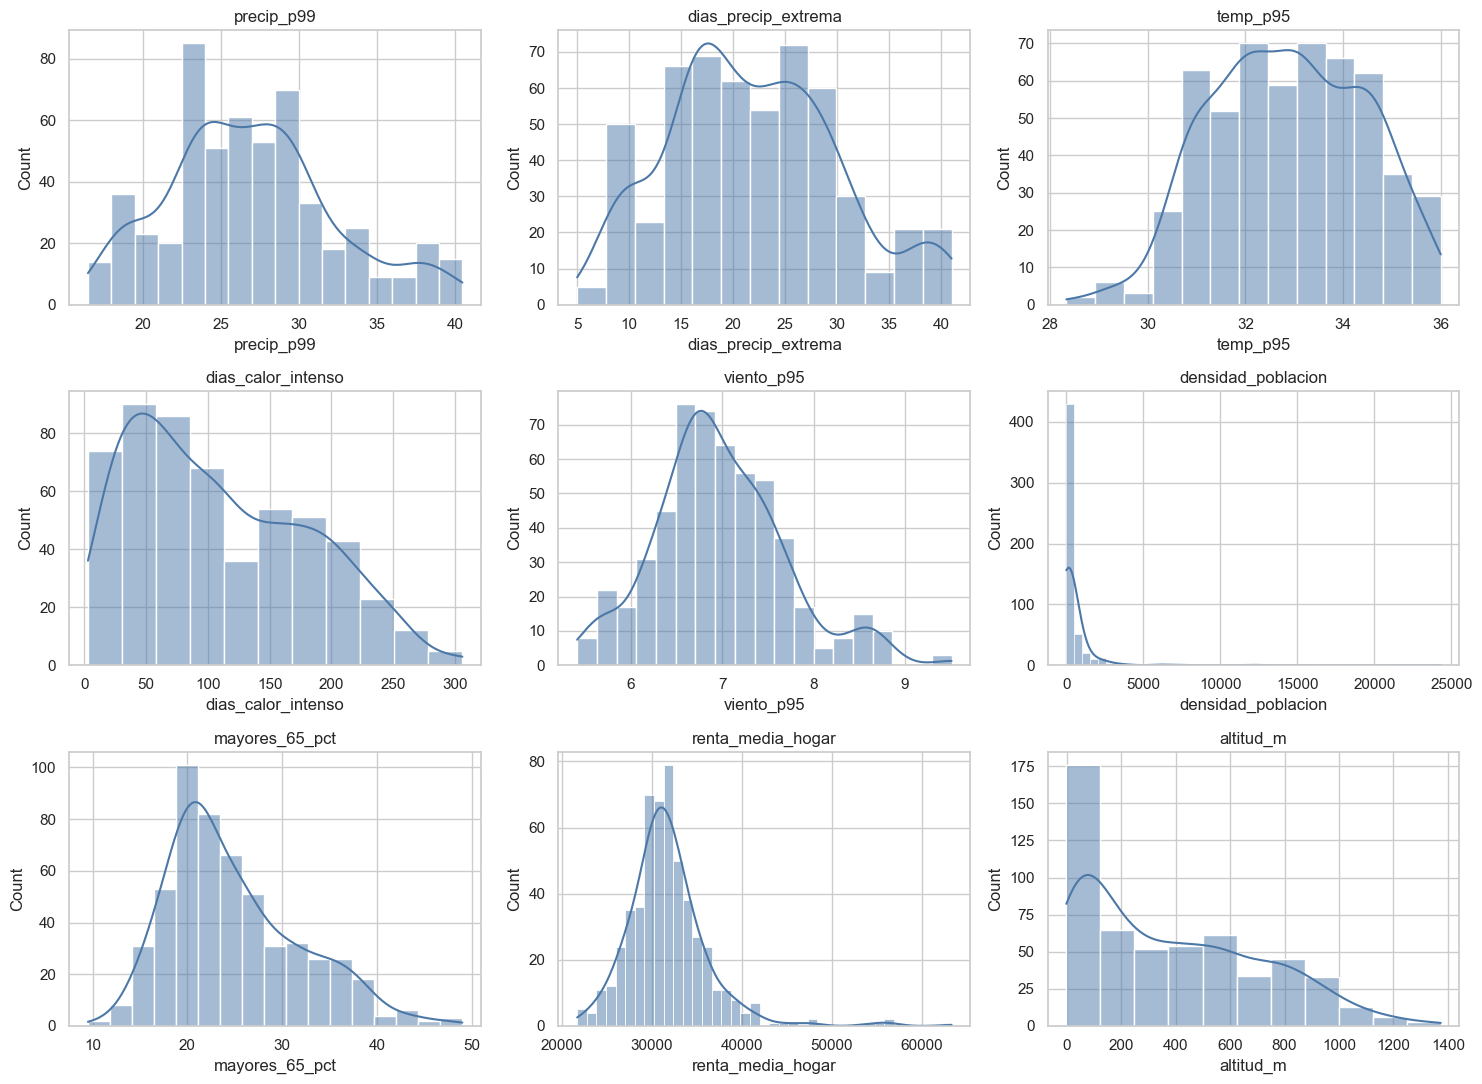

In [12]:
plot_cols = [
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df_mun[col], kde=True, ax=ax, color="#4c78a8")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [13]:
ranking_cols = [
    "municipio",
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
]

print("Top municipios por precipitacion extrema (p99):")
display(df_mun.sort_values("precip_p99", ascending=False)[ranking_cols].head(15))

print("Top municipios por dias de calor intenso:")
display(df_mun.sort_values("dias_calor_intenso", ascending=False)[ranking_cols].head(15))

print("Top municipios por viento intenso (p95):")
display(df_mun.sort_values("viento_p95", ascending=False)[ranking_cols].head(15))

Top municipios por precipitacion extrema (p99):


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
49,Almiserà,40.481348,41,33.088251,109,6.647643,37.22,25.71,31822.0,409.0
270,Llutxent,40.481348,41,33.088251,109,6.647643,57.67,22.06,31019.0,409.0
166,Castellonet de la Conquesta,40.481348,41,33.088251,109,6.647643,29.19,24.05,41936.0,409.0
6,Aielo de Rugat,40.481348,41,33.088251,109,6.647643,20.71,35.40,43758.0,409.0
377,Ròtova,40.481348,41,33.088251,109,6.647643,167.52,27.29,33863.0,409.0
100,Benicolet,40.481348,41,33.088251,109,6.647643,53.82,31.98,29760.0,409.0
424,Terrateig,40.481348,41,33.088251,109,6.647643,46.17,27.53,33030.0,409.0
298,Montitxelvo/Montichelvo,40.481348,41,33.088251,109,6.647643,67.42,24.60,32686.0,409.0
266,Llocnou de Sant Jeroni,40.481348,41,33.088251,109,6.647643,91.80,25.34,34039.0,409.0
477,Xeresa,39.056945,39,32.472809,83,7.446172,142.73,19.19,36055.0,135.0


Top municipios por dias de calor intenso:


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
360,Rafal,18.682162,10,36.000543,306,6.362503,3099.39,14.00,29469.0,17.0
199,Cox,18.682162,10,36.000543,306,6.362503,460.68,15.48,32330.0,17.0
365,Redován,18.682162,10,36.000543,306,6.362503,876.70,16.00,29722.0,17.0
132,Bigastro,18.682162,10,36.000543,306,6.362503,1839.14,16.18,30686.0,17.0
93,Benferri,17.933191,11,35.917022,285,6.263042,169.67,17.78,30649.0,180.0
247,Granja de Rocamora,18.123152,10,35.608819,265,6.391219,386.84,15.64,31126.0,84.0
15,Albatera,18.123152,10,35.608819,265,6.391219,219.23,15.97,29376.0,84.0
220,Estubeny,29.572659,26,35.687958,257,6.512214,17.13,34.55,27166.0,193.0
454,Vallés,29.572659,26,35.687958,257,6.512214,130.26,19.88,28947.0,193.0
374,Rotglà i Corberà,29.572659,26,35.687958,257,6.512214,186.71,22.09,32975.0,193.0


Top municipios por viento intenso (p95):


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
482,Xàbia/Jávea,29.636967,29,30.192072,9,9.511220,444.17,22.77,32978.0,108.0
239,Gata de Gorgos,29.636967,29,30.192072,9,9.511220,332.65,21.02,31582.0,108.0
211,Dénia,29.636967,29,30.192072,9,9.511220,711.07,21.26,33138.0,108.0
453,Vallibona,29.748676,27,30.636164,29,8.853558,0.69,25.40,26601.0,633.0
387,San Rafael del Río,29.374672,24,32.132782,60,8.841627,25.17,27.99,26443.0,283.0
154,Canet lo Roig,29.480974,27,31.431818,46,8.815587,10.40,33.62,28556.0,429.0
373,Rossell,29.480974,27,31.431818,46,8.815587,12.14,28.30,27148.0,429.0
343,Piles,36.642154,38,31.055512,39,8.684321,806.46,18.21,31100.0,11.0
289,Miramar,36.642154,38,31.055512,39,8.684321,1234.00,21.37,32129.0,11.0
314,Oliva,36.642154,38,31.055512,39,8.684321,445.35,21.98,31571.0,11.0


## 6. Relaciones entre clima, territorio y altitud

Se estudian correlaciones entre indicadores climaticos y variables territoriales. Este bloque no pretende demostrar causalidad, sino detectar relaciones descriptivas utiles para orientar fases posteriores.


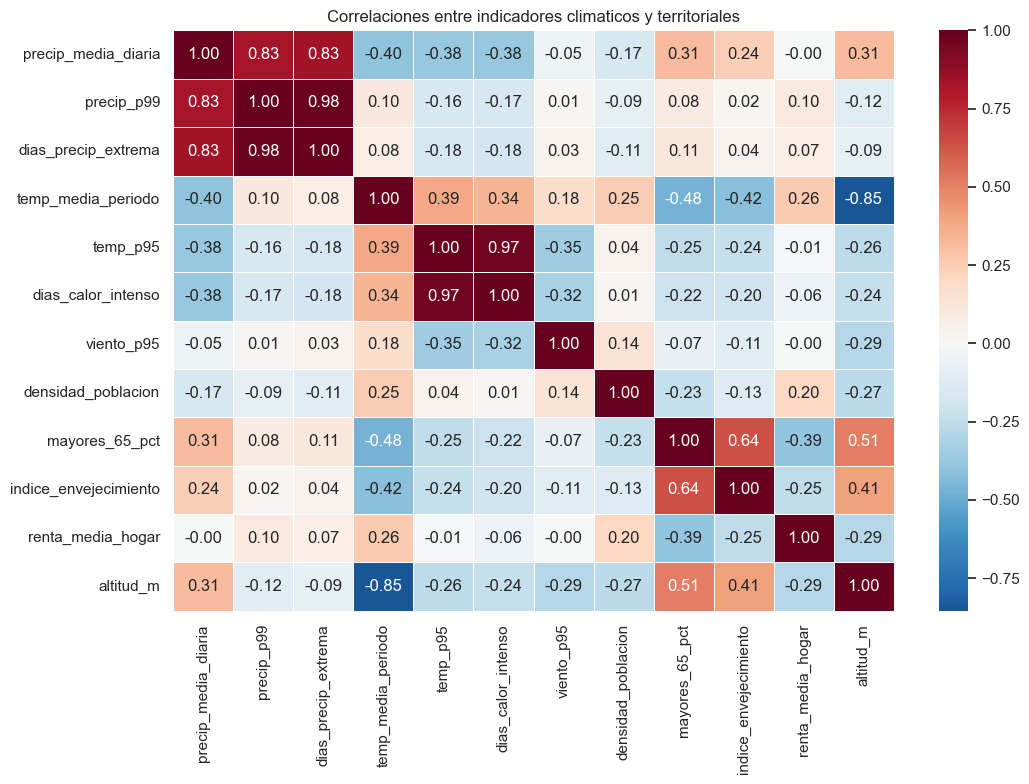

In [14]:
corr_cols = [
    "precip_media_diaria",
    "precip_p99",
    "dias_precip_extrema",
    "temp_media_periodo",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "indice_envejecimiento",
    "renta_media_hogar",
    "altitud_m",
]

corr = df_mun[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlaciones entre indicadores climaticos y territoriales")
plt.tight_layout()
plt.show()

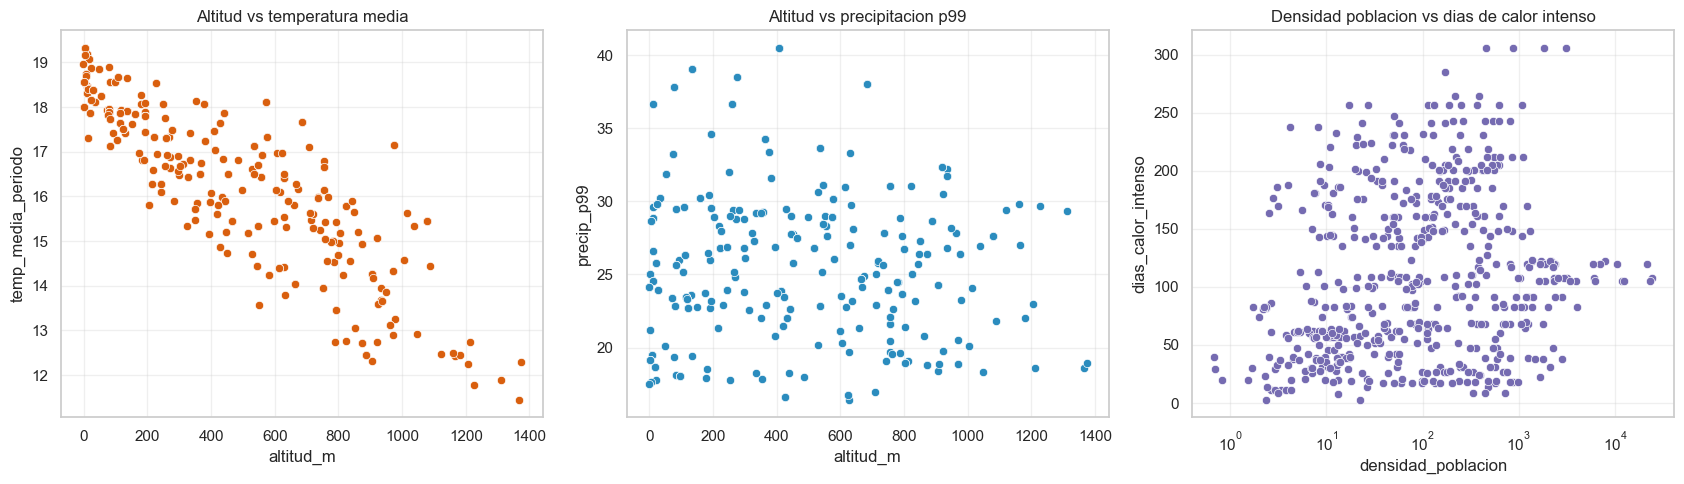

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(data=df_mun, x="altitud_m", y="temp_media_periodo", ax=axes[0], color="#d95f0e")
axes[0].set_title("Altitud vs temperatura media")

sns.scatterplot(data=df_mun, x="altitud_m", y="precip_p99", ax=axes[1], color="#2b8cbe")
axes[1].set_title("Altitud vs precipitacion p99")

sns.scatterplot(data=df_mun, x="densidad_poblacion", y="dias_calor_intenso", ax=axes[2], color="#756bb1")
axes[2].set_xscale("log")
axes[2].set_title("Densidad poblacion vs dias de calor intenso")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Indices exploratorios de peligro climatico y vulnerabilidad

Se construyen indices normalizados preliminares para resumir informacion. Estos indices no son todavia un modelo final de riesgo, sino una herramienta exploratoria para ordenar municipios y detectar combinaciones de exposicion climatica y vulnerabilidad territorial.


In [16]:
def minmax(series: pd.Series, reverse: bool = False) -> pd.Series:
    series = pd.to_numeric(series, errors="coerce")
    filled = series.fillna(series.median())
    spread = filled.max() - filled.min()
    if spread == 0:
        scaled = pd.Series(0.0, index=series.index)
    else:
        scaled = (filled - filled.min()) / spread
    return 1 - scaled if reverse else scaled

# Peligro climatico: intensidad/frecuencia de precipitacion, calor y viento.
df_mun["score_precip"] = minmax(df_mun["precip_p99"])
df_mun["score_calor"] = minmax(df_mun["dias_calor_intenso"])
df_mun["score_viento"] = minmax(df_mun["viento_p95"])

df_mun["score_peligro_climatico"] = df_mun[["score_precip", "score_calor", "score_viento"]].mean(axis=1)

# Vulnerabilidad territorial: poblacion expuesta, envejecimiento y menor renta.
df_mun["score_densidad"] = minmax(df_mun["densidad_poblacion"])
df_mun["score_mayores"] = minmax(df_mun["mayores_65_pct"])
df_mun["score_renta_baja"] = minmax(df_mun["renta_media_hogar"], reverse=True)

df_mun["score_vulnerabilidad"] = df_mun[["score_densidad", "score_mayores", "score_renta_baja"]].mean(axis=1)

df_mun["score_riesgo_preliminar"] = (
    0.6 * df_mun["score_peligro_climatico"]
    + 0.4 * df_mun["score_vulnerabilidad"]
)

display(
    df_mun[
        [
            "municipio",
            "score_peligro_climatico",
            "score_vulnerabilidad",
            "score_riesgo_preliminar",
            "precip_p99",
            "dias_calor_intenso",
            "viento_p95",
            "densidad_poblacion",
            "mayores_65_pct",
            "renta_media_hogar",
        ]
    ].sort_values("score_riesgo_preliminar", ascending=False).head(20)
)

,municipio,score_peligro_climatico,score_vulnerabilidad,score_riesgo_preliminar,precip_p99,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar
220,Estubeny,0.551178,0.501129,0.531159,29.572659,257,6.512214,17.13,34.55,27166.0
507,l'Atzúbia,0.552879,0.483333,0.525060,37.833611,68,7.682318,40.12,35.94,30891.0
403,Sempere,0.509625,0.533438,0.519150,34.597036,191,6.036749,8.66,42.42,NaN
21,Alcalalí,0.497655,0.550479,0.518785,31.865981,27,8.576506,99.19,40.85,27781.0
100,Benicolet,0.550649,0.459171,0.514058,40.481348,109,6.647643,53.82,31.98,29760.0
436,Torrella,0.551178,0.455931,0.513079,29.572659,257,6.512214,129.96,30.46,28694.0
253,Herbers,0.459654,0.573791,0.505309,27.799016,40,8.626967,2.51,42.65,26601.0
384,San Fulgencio,0.434950,0.605117,0.503017,19.159408,212,7.468550,471.80,42.84,23694.0
418,Sumacàrcer,0.550873,0.430831,0.502856,30.225485,231,6.749098,50.41,28.99,30143.0
357,Quatretonda,0.565828,0.406444,0.502075,38.506486,160,6.480994,49.87,27.91,32049.0


## 8. Representacion espacial

Se cruza la tabla municipal agregada con la geometria municipal para representar espacialmente algunos indicadores. Estos mapas permiten comprobar si los resultados muestran patrones territoriales coherentes.


In [17]:
gdf_mun = gpd.read_file(MUNICIPIOS_GEO_FILE)

gdf_analysis = gdf_mun.merge(
    df_mun,
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_mun))
print("Municipios tras merge:", len(gdf_analysis))
print("Sin score de riesgo:", gdf_analysis["score_riesgo_preliminar"].isna().sum())

display(gdf_analysis[["municipio", "score_riesgo_preliminar", "score_peligro_climatico", "score_vulnerabilidad"]].head())

Municipios en geometria: 542
Municipios tras merge: 542
Sin score de riesgo: 0


,municipio,score_riesgo_preliminar,score_peligro_climatico,score_vulnerabilidad
0,l'Atzúbia,0.525060,0.552879,0.483333
1,Agost,0.308108,0.276492,0.355532
2,Agres,0.404786,0.418157,0.384731
3,Aigües,0.290654,0.261318,0.334659
4,Albatera,0.366597,0.391365,0.329444


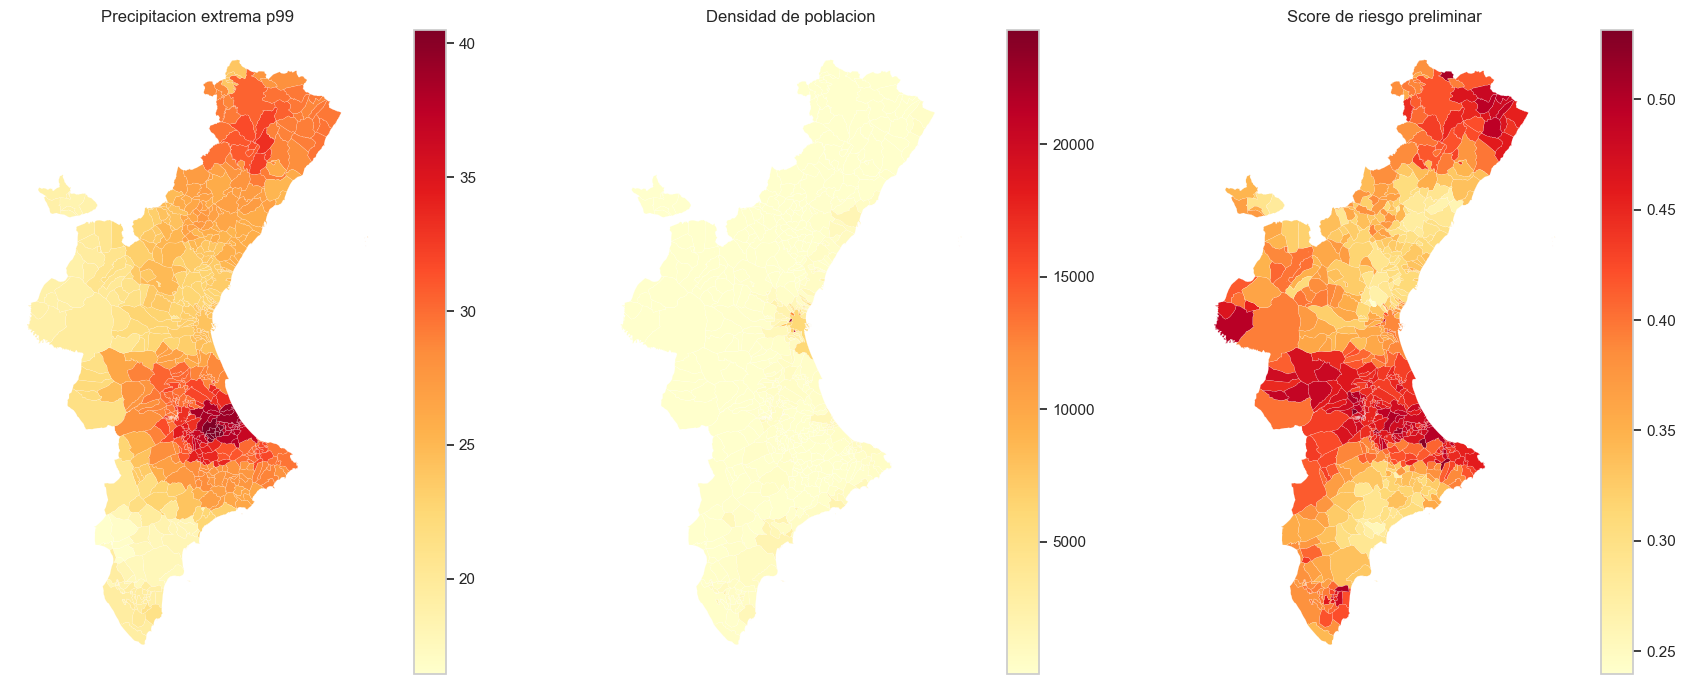

In [18]:
map_cols = [
    ("precip_p99", "Precipitacion extrema p99"),
    ("densidad_poblacion", "Densidad de poblacion"),
    ("score_riesgo_preliminar", "Score de riesgo preliminar"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (col, title) in zip(axes, map_cols):
    gdf_analysis.plot(
        column=col,
        ax=ax,
        legend=True,
        cmap="YlOrRd",
        linewidth=0.1,
        edgecolor="white",
        missing_kwds={"color": "lightgrey", "label": "Sin datos"},
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Mapa interactivo opcional si folium esta instalado.
try:
    import folium

    interactive_file = MAPS / "mapa_riesgo_preliminar.html"
    gdf_analysis_4326 = gdf_analysis.to_crs(epsg=4326)

    m = gdf_analysis_4326.explore(
        column="score_riesgo_preliminar",
        cmap="YlOrRd",
        legend=True,
        tooltip=[
            "municipio",
            "score_riesgo_preliminar",
            "score_peligro_climatico",
            "score_vulnerabilidad",
            "precip_p99",
            "dias_calor_intenso",
            "densidad_poblacion",
            "altitud_m",
        ],
        style_kwds={"weight": 0.3, "fillOpacity": 0.75},
    )
    m.save(interactive_file)
    print("Mapa interactivo guardado en:", interactive_file)
except Exception as exc:
    print("No se ha generado mapa interactivo. Motivo:", exc)

No se ha generado mapa interactivo. Motivo: The 'folium>=0.12', 'matplotlib' and 'mapclassify' packages are required for 'explore()'. You can install them using 'conda install -c conda-forge "folium>=0.12" matplotlib mapclassify' or 'pip install "folium>=0.12" matplotlib mapclassify'.


## 9. Exportacion del dataset analitico municipal

La tabla agregada municipal se guarda como salida del Notebook 3. Esta tabla es mas adecuada para rankings, mapas, segmentacion territorial y modelos posteriores a escala municipal.


In [20]:
df_mun.to_csv(ANALYTIC_MUNICIPAL_FILE, index=False)

print("Dataset analitico municipal guardado en:", ANALYTIC_MUNICIPAL_FILE)
print("Shape:", df_mun.shape)

display(df_mun.head())

Dataset analitico municipal guardado en: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv
Shape: (542, 41)


,municipio,CODNUT2,CODNUT3,precip_media_diaria,precip_max_dia,precip_p95,precip_p99,dias_precip_intensa,dias_precip_extrema,temp_media_periodo,temp_max_media,temp_max_abs,temp_p95,dias_calor_intenso,temp_min_abs,viento_medio_periodo,viento_max_abs,viento_p95,dias_viento_intenso,amplitud_termica_media,lon,lat,dist_metros,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar,altitud_m,score_precip,score_calor,score_viento,score_peligro_climatico,score_densidad,score_mayores,score_renta_baja,score_vulnerabilidad,score_riesgo_preliminar
0,Ademuz,ES52,ES523,1.459790,33.931183,8.618695,18.368174,105,6,12.317326,17.969816,37.645905,32.069465,60,-9.880951,2.354678,9.956327,6.782720,78,10.909306,-1.2,40.1,5806.682345,100.2900,46001,1015.0,10.12,26.80,11.82,226.67,27809.0,907.0,0.079986,0.188119,0.335031,0.201045,0.000388,0.437358,0.853748,0.430498,0.292826
1,Ador,ES52,ES523,2.102830,143.414780,11.106972,37.833611,138,38,17.895431,21.608291,39.722076,31.999384,68,1.046295,3.106088,13.624233,7.682318,179,7.251112,-0.2,38.9,2485.383043,13.8364,46002,1755.0,126.84,20.42,11.36,179.70,31572.0,79.0,0.889841,0.214521,0.554274,0.552879,0.005191,0.275880,0.763319,0.348130,0.470979
2,Agost,ES52,ES521,1.094086,75.414550,5.610108,18.520694,75,11,18.075257,22.611731,39.302155,32.961835,97,-0.357025,2.732337,13.176444,7.184352,117,8.828438,-0.6,38.4,6996.059580,66.6538,3002,5225.0,78.39,20.27,13.84,146.47,30407.0,181.0,0.086332,0.310231,0.432913,0.276492,0.003197,0.272083,0.791315,0.355532,0.308108
3,Agres,ES52,ES521,1.826327,106.037970,9.551134,31.017301,123,28,16.650944,22.090261,42.157623,34.419501,176,-3.486420,1.976098,9.044077,5.725050,22,10.334956,-0.5,38.8,2075.930152,25.8457,3003,623.0,24.10,24.80,11.36,218.31,31440.0,756.0,0.606250,0.570957,0.077263,0.418157,0.000964,0.386738,0.766491,0.384731,0.404786
4,Agullent,ES52,ES523,1.690449,98.432850,9.223645,28.305807,113,25,16.429414,22.035266,42.036530,34.757147,200,-3.988373,1.995531,9.247415,5.912659,29,10.584102,-0.6,38.8,5559.636342,16.2440,46004,2438.0,150.09,21.43,12.46,172.04,31085.0,556.0,0.493439,0.650165,0.122986,0.422197,0.006147,0.301443,0.775022,0.360871,0.397666


## 10. Conclusiones provisionales del analisis

Puntos a completar tras ejecutar el notebook:

- La serie temporal permite verificar la estacionalidad de temperatura, precipitacion y viento.
- La agregacion municipal permite comparar municipios con criterios homogeneos.
- La altitud ayuda a contextualizar diferencias climaticas entre zonas de interior, costa y areas elevadas.
- Los indices exploratorios permiten ordenar municipios, pero no deben interpretarse aun como un modelo definitivo de riesgo.
- La siguiente fase deberia profundizar en segmentacion, validacion de pesos e interpretacion para Analisis de Negocio.
